In [17]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv")



In [8]:
df.head()

,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False
1,1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,...,False,False,False,False,False,False,False,False,False,False
2,2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,...,False,False,False,False,False,False,False,False,False,False
3,3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,...,False,False,False,False,False,False,False,False,False,False
4,4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df.shape

(1000, 33)

In [10]:
years = sorted(df["Year"].unique())
ratings_yr = [df.loc[df["Year"] == year, "Rating"] for year in years]
f, p = stats.f_oneway(*ratings_yr)

dfb = len(years) - 1
dfw = len(df) - len(years)
alpha = 0.05
critical = stats.f.ppf(1 - alpha, dfb, dfw)
print(f"f={f:.4f}, critical={critical:.4f}, p={p:.4f}")


f=6.0455, critical=1.8403, p=0.0000


In [11]:


years = sorted(df["Year"].unique())
ratings_yr = [df.loc[df["Year"] == year, "Rating"] for year in years]

tukey = pairwise_tukeyhsd(df["Rating"], df["Year"], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  2006   2007    0.009    1.0  -0.598  0.6159  False
  2006   2008  -0.3404 0.7793   -0.95  0.2692  False
  2006   2009  -0.1642 0.9987 -0.7765  0.4481  False
  2006   2010  -0.2983 0.8695  -0.889  0.2923  False
  2006   2011  -0.2869 0.8894 -0.8716  0.2978  False
  2006   2012     -0.2 0.9905 -0.7828  0.3828  False
  2006   2013  -0.3129 0.7512 -0.8594  0.2335  False
  2006   2014  -0.2872 0.8273 -0.8273  0.2528  False
  2006   2015  -0.5226 0.0481 -1.0432  -0.002   True
  2006   2016  -0.6883 0.0002  -1.169 -0.2076   True
  2007   2008  -0.3493 0.6904 -0.9302  0.2315  False
  2007   2009  -0.1732 0.9971 -0.7569  0.4106  False
  2007   2010  -0.3073 0.7992 -0.8683  0.2537  False
  2007   2011  -0.2959 0.8247 -0.8506  0.2588  False
  2007   2012   -0.209 0.9803 -0.7617  0.3437  False
  2007   2013  -0.3219 0.6353 -0.8361  0.1923 

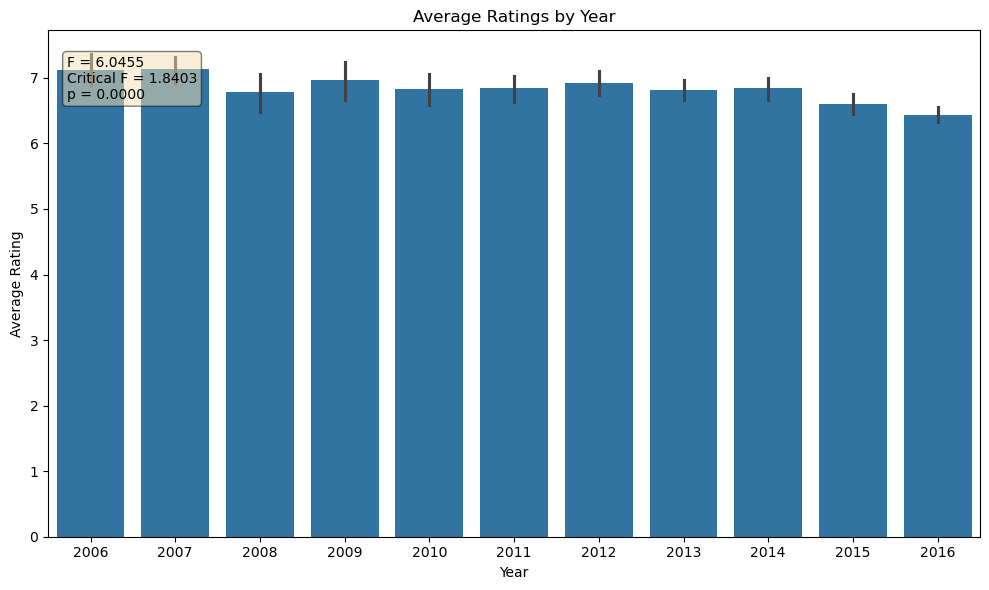

In [12]:
plt.figure(figsize=(10, 6))
bar = sns.barplot(data=df, x="Year", y="Rating", order=sorted(df["Year"].unique()))


textstr = f"F = {f:.4f}\nCritical F = {critical:.4f}\np = {p:.4f}"
bar.text(0.02, 0.95, textstr, transform=bar.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

bar.set(title="Average Ratings by Year", xlabel="Year", ylabel="Average Rating")
plt.tight_layout()
plt.show()

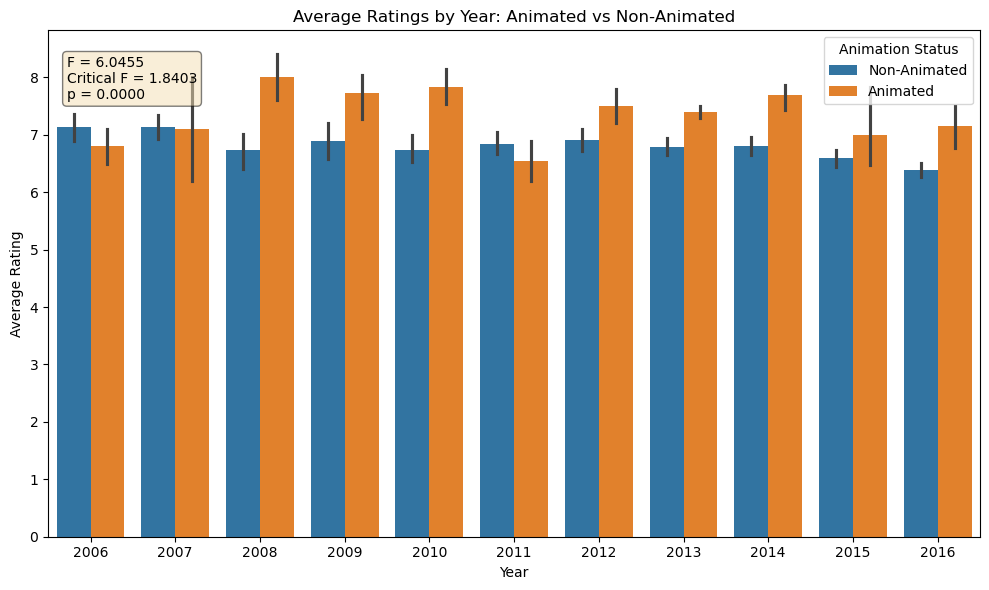

In [14]:
df["Animation Status"] = df["Animation"].map({True: "Animated", False: "Non-Animated"})

plt.figure(figsize=(10, 6))
bar = sns.barplot(data=df, x="Year", y="Rating", hue="Animation Status",
                  order=sorted(df["Year"].unique()))

textstr = f"F = {f:.4f}\nCritical F = {critical:.4f}\np = {p:.4f}"
bar.text(0.02, 0.95, textstr, transform=bar.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

bar.set(title="Average Ratings by Year: Animated vs Non-Animated",
        xlabel="Year", ylabel="Average Rating")
plt.tight_layout()
plt.show()

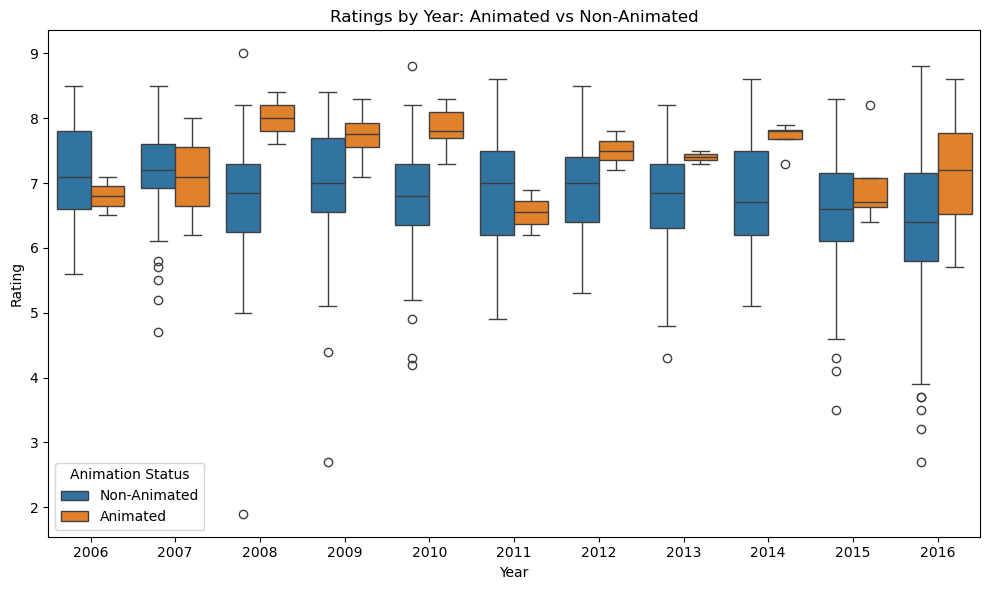

In [15]:
plt.figure(figsize=(10, 6))
box = sns.boxplot(data=df, x="Year", y="Rating", hue="Animation Status",
                  order=sorted(df["Year"].unique()))

box.set(title="Ratings by Year: Animated vs Non-Animated",
        xlabel="Year", ylabel="Rating")
plt.tight_layout()
plt.show()

In [16]:
group1 = df.loc[(df["Action"] == True) | (df["Adventure"] == True) | (df["Sci-Fi"] == True), "Rating"]
group2 = df.loc[df["Drama"] == True, "Rating"]
group3 = df.loc[(df["Comedy"] == True) | (df["Romance"] == True), "Rating"]
group4 = df.loc[(df["Animation"] == True) | (df["Adventure"] == True) | (df["Comedy"] == True), "Rating"]

f, p = stats.f_oneway(group1, group2, group3, group4)

dfb = 3  
dfw = len(group1) + len(group2) + len(group3) + len(group4) - 4
alpha = 0.05
critical = stats.f.ppf(1 - alpha, dfb, dfw)

print(f"f={f:.4f}, critical={critical:.4f}, p={p:.4f}")

f=9.7919, critical=2.6099, p=0.0000


              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2        meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------
   Action/Adv/Sci-Fi Animation/Adv/Comedy  -0.0217 0.9827 -0.1724  0.129  False
   Action/Adv/Sci-Fi       Comedy/Romance  -0.0087 0.9991 -0.1727 0.1553  False
   Action/Adv/Sci-Fi                Drama   0.2414 0.0002  0.0928   0.39   True
Animation/Adv/Comedy       Comedy/Romance    0.013 0.9968  -0.148 0.1741  False
Animation/Adv/Comedy                Drama   0.2631    0.0  0.1178 0.4085   True
      Comedy/Romance                Drama   0.2501 0.0003   0.091 0.4091   True
-------------------------------------------------------------------------------


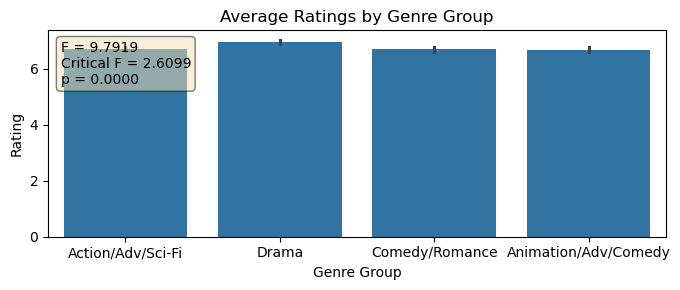

In [19]:

ratings = np.concatenate([group1, group2, group3, group4])
labels = (["Action/Adv/Sci-Fi"] * len(group1) + 
          ["Drama"] * len(group2) + 
          ["Comedy/Romance"] * len(group3) + 
          ["Animation/Adv/Comedy"] * len(group4))

tukey = pairwise_tukeyhsd(ratings, labels, alpha=0.05)
print(tukey)

genre_col = pd.Series(labels, name="Genre Group")
rating_col = pd.Series(ratings, name="Rating")
df_genres = pd.concat([rating_col, genre_col], axis=1)

plt.figure(figsize=(7, 3))
bar = sns.barplot(data=df_genres, x="Genre Group", y="Rating")

textstr = f"F = {f:.4f}\nCritical F = {critical:.4f}\np = {p:.4f}"
bar.text(0.02, 0.95, textstr, transform=bar.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

bar.set(title="Average Ratings by Genre Group")
plt.tight_layout()
plt.show()